Logistic Regression

In [1]:
import numpy as np
import pandas as pd

from rice_ml.supervised_learning import LogisticRegression

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
input_file = "wdbc.data"
columns = [
    'ID', 'Diagnosis',
    'radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1',
    'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1',
    
    'radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2',
    'compactness2', 'concavity2', 'concave_points2', 'symmetry2', 'fractal_dimension2',
    
    'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3',
    'compactness3', 'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3'
]
df = pd.read_csv(input_file, header=None, names=columns)

df

,ID,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [13]:
X = df.drop(['Diagnosis', "ID"], axis=1)
X = df[['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1',
    'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1',
    
    'radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2',
    'compactness2', 'concavity2', 'concave_points2', 'symmetry2', 'fractal_dimension2',
    
    'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3',
    'compactness3', 'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3']] 
y = df['Diagnosis']

y = y.replace({"M": 1, "B": 0})

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=51, stratify=y
)

In [28]:
model = LogisticRegression(learning_rate=0.1, n_iterations=300)
model.train(X_train, y_train)



In [29]:
y_pred = model.predict(X_test)
y_prob = model.predict_prob(X_test)
y_test = y_test.astype(int)

print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print()
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
print("Confusion Matrix:\n", cm)

Test Accuracy: 0.9737

Confusion Matrix:
 [[40  2]
 [ 1 71]]


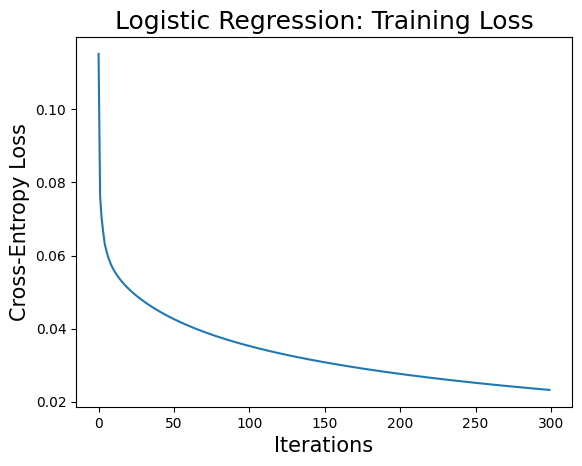

In [6]:
plt.figure
plt.plot(model.errors_)
plt.xlabel('Iterations', fontsize=15)
plt.ylabel('Cross-Entropy Loss', fontsize=15)
plt.title('Logistic Regression: Training Loss', fontsize=18)
plt.show()